# DATA UNDERSTANDING

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("../static/plots", exist_ok=True)

In [2]:
df=pd.read_csv("train.csv")
df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [4]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [5]:
df.shape

(1460, 81)

In [6]:
df.dtypes

Id                 int64
MSSubClass         int64
MSZoning             str
LotFrontage      float64
LotArea            int64
                  ...   
MoSold             int64
YrSold             int64
SaleType             str
SaleCondition        str
SalePrice          int64
Length: 81, dtype: object

In [7]:
df.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [8]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [9]:
df.dtypes[df.isnull().sum()>0]

LotFrontage     float64
Alley               str
MasVnrType          str
MasVnrArea      float64
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Electrical          str
FireplaceQu         str
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
PoolQC              str
Fence               str
MiscFeature         str
dtype: object

In [10]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df=df.drop("Id",axis=1)

In [13]:
num_col=df.select_dtypes(include=['int64','float64'])
num_col

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
0,60,65.0,8450,7,5,2003,2003,196.0,706,0,...,0,61,0,0,0,0,0,2,2008,208500
1,20,80.0,9600,6,8,1976,1976,0.0,978,0,...,298,0,0,0,0,0,0,5,2007,181500
2,60,68.0,11250,7,5,2001,2002,162.0,486,0,...,0,42,0,0,0,0,0,9,2008,223500
3,70,60.0,9550,7,5,1915,1970,0.0,216,0,...,0,35,272,0,0,0,0,2,2006,140000
4,60,84.0,14260,8,5,2000,2000,350.0,655,0,...,192,84,0,0,0,0,0,12,2008,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,60,62.0,7917,6,5,1999,2000,0.0,0,0,...,0,40,0,0,0,0,0,8,2007,175000
1456,20,85.0,13175,6,6,1978,1988,119.0,790,163,...,349,0,0,0,0,0,0,2,2010,210000
1457,70,66.0,9042,7,9,1941,2006,0.0,275,0,...,0,60,0,0,0,0,2500,5,2010,266500
1458,20,68.0,9717,5,6,1950,1996,0.0,49,1029,...,366,0,112,0,0,0,0,4,2010,142125


In [14]:
cat_col=df.select_dtypes(include=['object'])
cat_col

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/2959212981.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col=df.select_dtypes(include=['object'])


,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
0,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
2,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
3,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,...,Detchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Abnorml
4,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Gilbert,Norm,...,Attchd,RFn,TA,TA,Y,NaN,NaN,NaN,WD,Normal
1456,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NWAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,MnPrv,NaN,WD,Normal
1457,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,Crawfor,Norm,...,Attchd,RFn,TA,TA,Y,NaN,GdPrv,Shed,WD,Normal
1458,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,NaN,NaN,NaN,WD,Normal


In [15]:
cat_col.columns

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

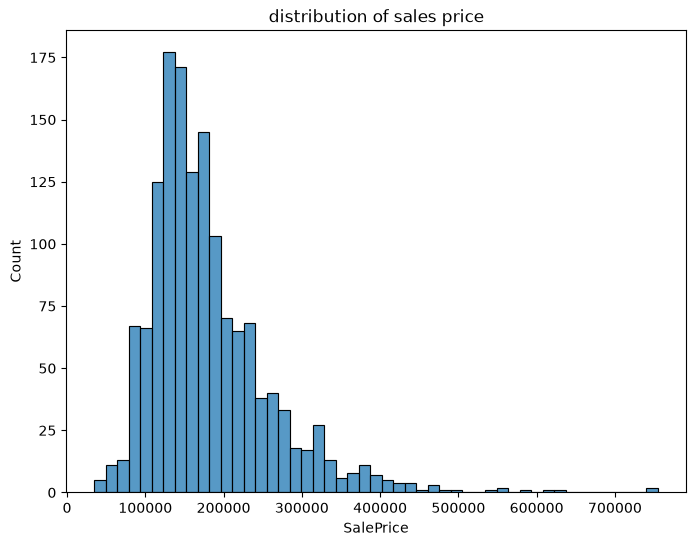

In [16]:
plt.figure(figsize=(8,6))
sns.histplot(df['SalePrice'])
plt.title("distribution of sales price")

plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/distribution.png", dpi=300)
plt.show()
plt.close()

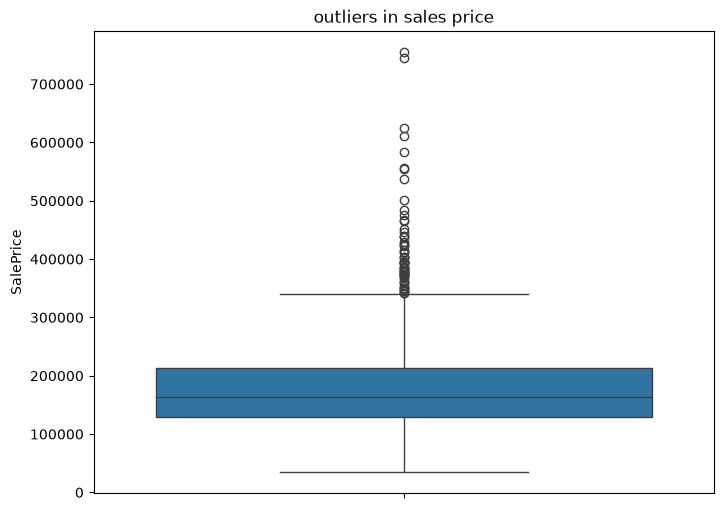

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(df['SalePrice'])
plt.title("outliers in sales price")
plt.show()

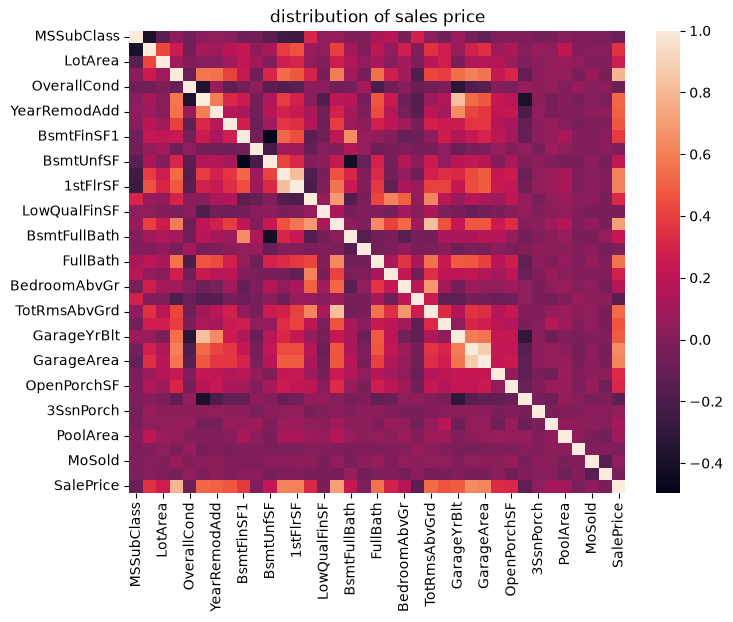

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True))
plt.title("distribution of sales price")
plt.show()

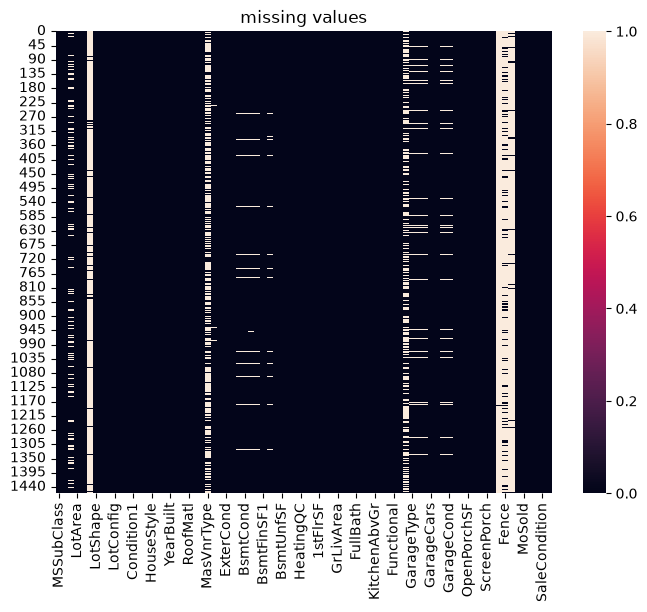

In [19]:
plt.figure(figsize=(8,6))
sns.heatmap(df.isnull())
plt.title("missing values")
plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/missing_values.png", dpi=300)
plt.show()
plt.close()

# DATA PROCESSING

In [20]:
df.isnull().sum()

MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
Street             0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 80, dtype: int64

In [21]:
df.isnull().sum()[df.isnull().sum()>0]

LotFrontage      259
Alley           1369
MasVnrType       872
MasVnrArea         8
BsmtQual          37
BsmtCond          37
BsmtExposure      38
BsmtFinType1      37
BsmtFinType2      38
Electrical         1
FireplaceQu      690
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
PoolQC          1453
Fence           1179
MiscFeature     1406
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df.dtypes[df.isnull().sum()>0]

LotFrontage     float64
Alley               str
MasVnrType          str
MasVnrArea      float64
BsmtQual            str
BsmtCond            str
BsmtExposure        str
BsmtFinType1        str
BsmtFinType2        str
Electrical          str
FireplaceQu         str
GarageType          str
GarageYrBlt     float64
GarageFinish        str
GarageQual          str
GarageCond          str
PoolQC              str
Fence               str
MiscFeature         str
dtype: object

In [24]:
cat_cols = [
    'Alley', 'MasVnrType', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu', 'GarageType', 'GarageFinish',
    'GarageQual', 'GarageCond', 'PoolQC',
    'Fence', 'MiscFeature'
]
for col in cat_cols:
    df[col] = df[col].fillna("None")

In [25]:
num_cols = ['LotFrontage', 'MasVnrArea', 'GarageYrBlt']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [26]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [27]:
df.isnull().sum()

MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 80, dtype: int64

In [28]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [29]:
df.drop_duplicates(inplace=True)

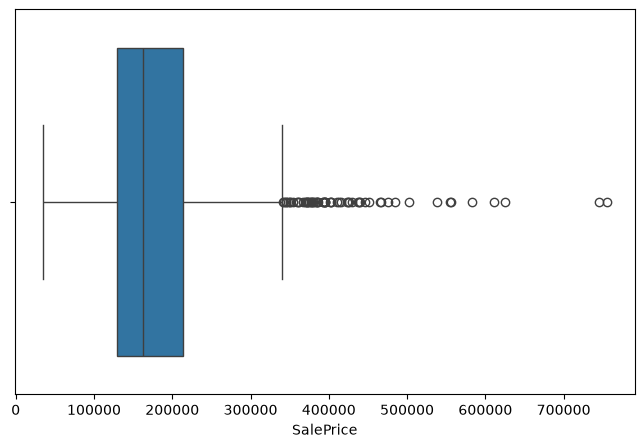

In [30]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['SalePrice'])
plt.show()

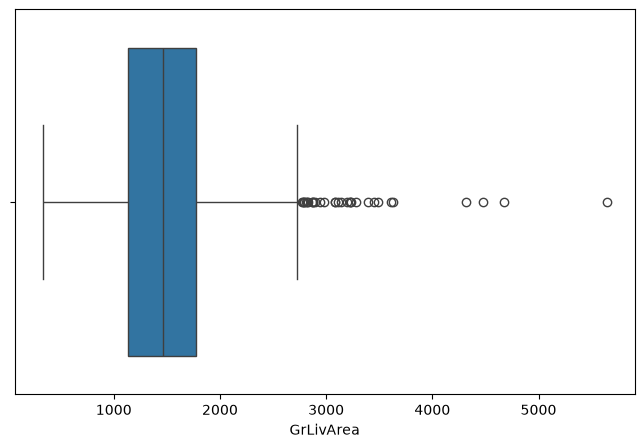

In [31]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['GrLivArea'])
plt.show()

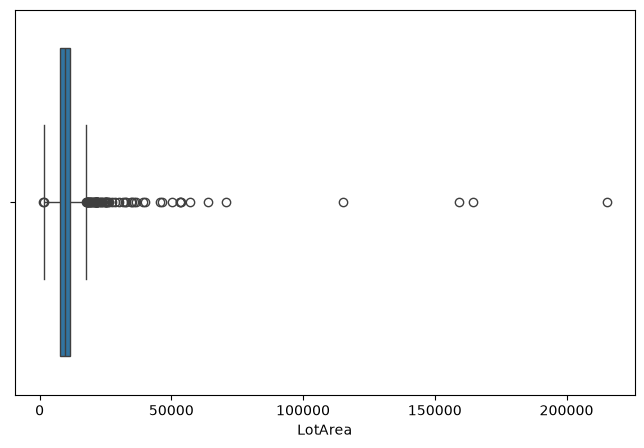

In [32]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['LotArea'])
plt.show()

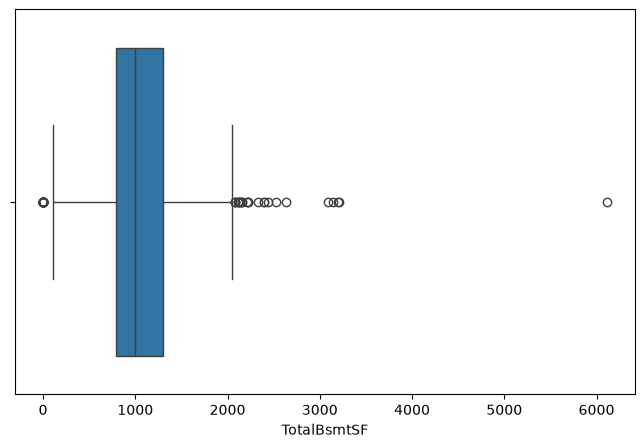

In [33]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['TotalBsmtSF'])
plt.show()

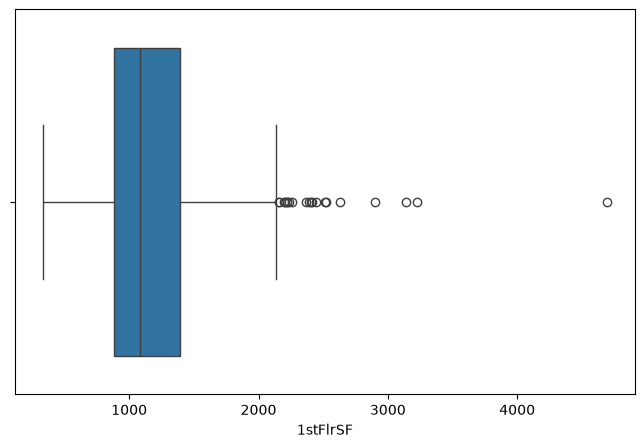

In [34]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['1stFlrSF'])
plt.show()

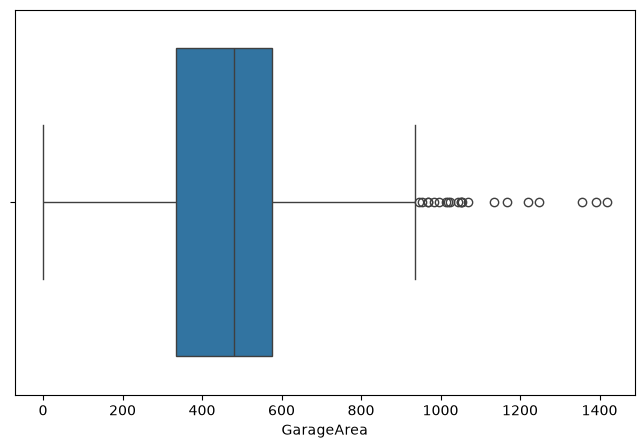

In [35]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['GarageArea'])
plt.show()

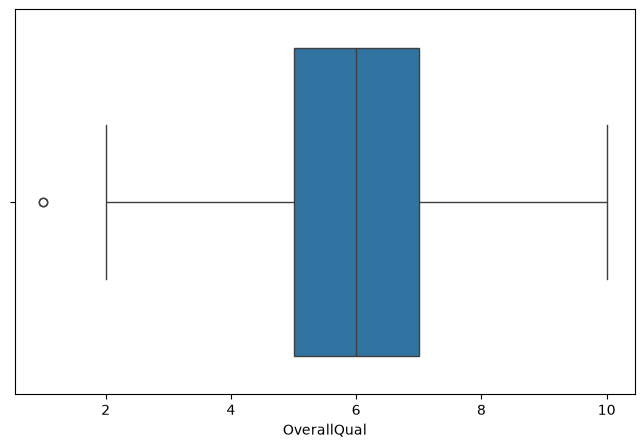

In [36]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['OverallQual'])
plt.show()

In [37]:
Q1 = df["SalePrice"].quantile(0.25)
Q3 = df["SalePrice"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

3937.5 340037.5


In [38]:
Q1 = df['GrLivArea'].quantile(0.25)
Q3 = df['GrLivArea'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [39]:
df.shape

(1460, 80)

In [40]:
Q1 = df["LotArea"].quantile(0.25)
Q3 = df["LotArea"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

1481.5 17673.5


In [41]:
Q1 = df["TotalBsmtSF"].quantile(0.25)
Q3 = df["TotalBsmtSF"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

42.0 2052.0


In [42]:
Q1 = df["1stFlrSF"].quantile(0.25)
Q3 = df["1stFlrSF"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

118.125 2155.125


In [43]:
Q1 = df["GarageArea"].quantile(0.25)
Q3 = df["GarageArea"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

-27.75 938.25


In [44]:
Q1 = df["OverallQual"].quantile(0.25)
Q3 = df["OverallQual"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print(lower, upper)

2.0 10.0


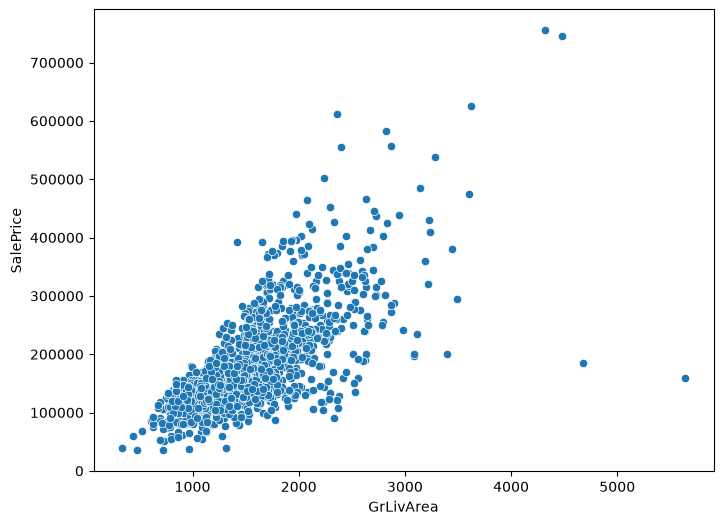

In [45]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['GrLivArea'],
    y=df['SalePrice']
)
plt.show()

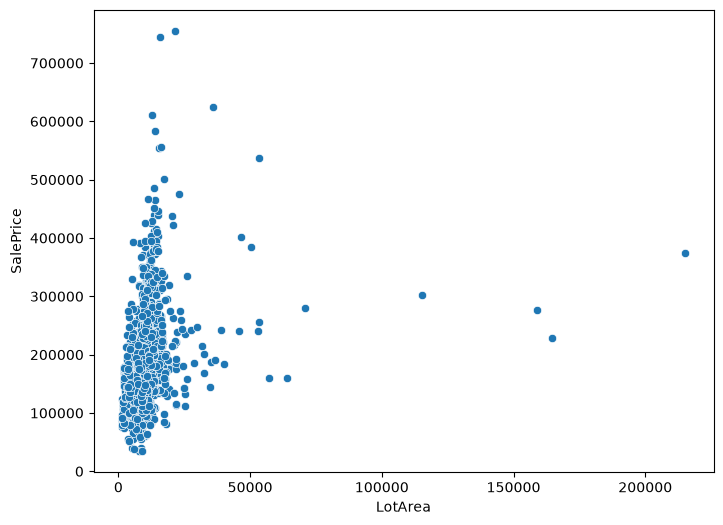

In [46]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['LotArea'],
    y=df['SalePrice']
)
plt.show()

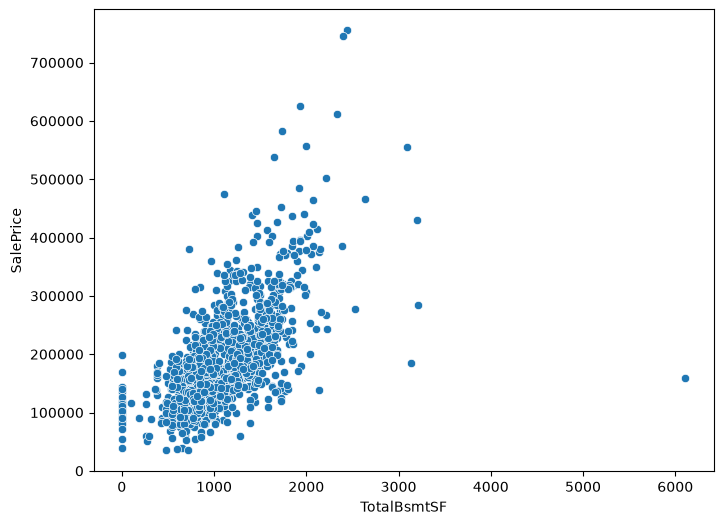

In [47]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['TotalBsmtSF'],
    y=df['SalePrice']
)
plt.show()

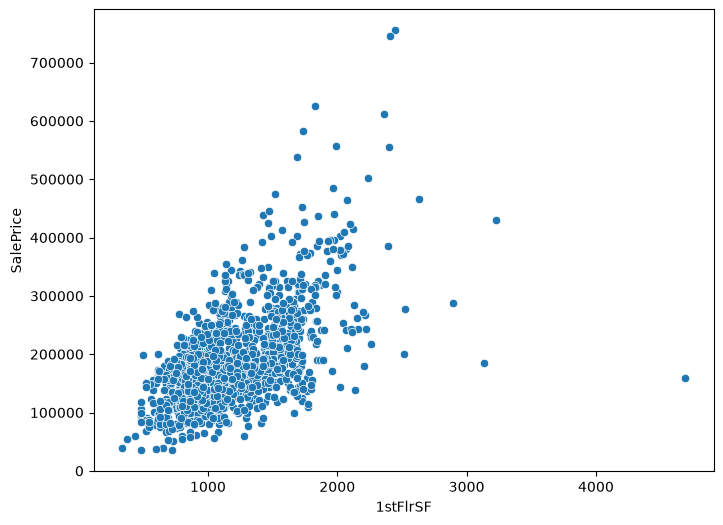

In [48]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['1stFlrSF'],
    y=df['SalePrice']
)
plt.show()

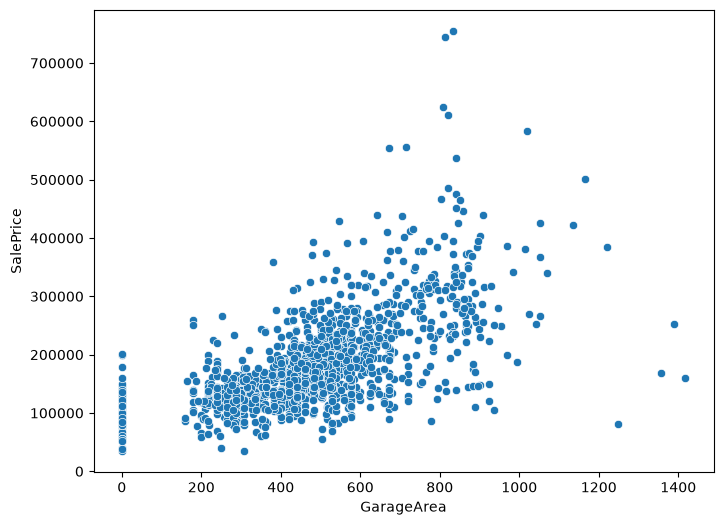

In [49]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['GarageArea'],
    y=df['SalePrice']
)
plt.show()

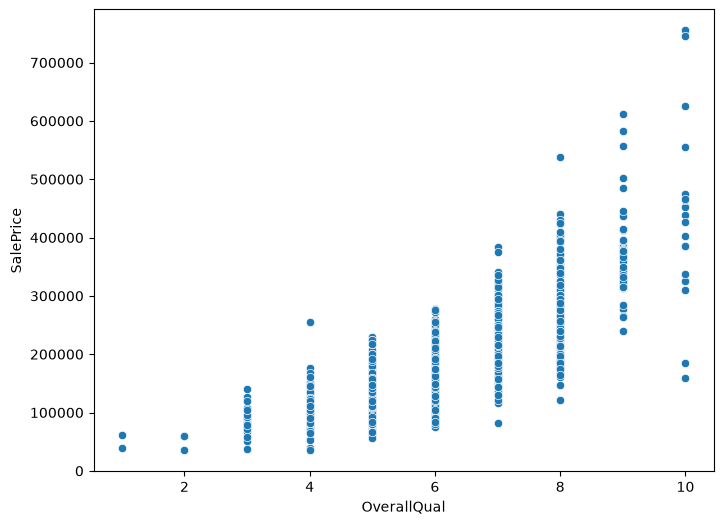

In [50]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['OverallQual'],
    y=df['SalePrice']
)
plt.show()

In [51]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/910776789.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include='object').columns


Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='str')

In [52]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [53]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [54]:
df.shape

(1460, 260)

In [55]:
df.select_dtypes(include='object').columns

Index([], dtype='str')

In [56]:
df.dtypes.value_counts()

int64      257
float64      3
Name: count, dtype: int64

In [57]:
num_cols = [
    'LotFrontage',
    'LotArea',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'LowQualFinSF',
    'GrLivArea',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'EnclosedPorch',
    '3SsnPorch',
    'ScreenPorch',
    'PoolArea',
    'MiscVal',
    'SalePrice'
]
skewness = df[num_cols].skew()
skewness.sort_values(ascending=False)

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
BsmtFinSF2        4.255261
ScreenPorch       4.122214
EnclosedPorch     3.089872
MasVnrArea        2.677616
LotFrontage       2.409147
OpenPorchSF       2.364342
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
1stFlrSF          1.376757
GrLivArea         1.366560
BsmtUnfSF         0.920268
2ndFlrSF          0.813030
GarageArea        0.179981
dtype: float64

In [58]:
high_skew = skewness[abs(skewness) > 0.75]
high_skew

LotFrontage       2.409147
LotArea          12.207688
MasVnrArea        2.677616
BsmtFinSF1        1.685503
BsmtFinSF2        4.255261
BsmtUnfSF         0.920268
TotalBsmtSF       1.524255
1stFlrSF          1.376757
2ndFlrSF          0.813030
LowQualFinSF      9.011341
GrLivArea         1.366560
WoodDeckSF        1.541376
OpenPorchSF       2.364342
EnclosedPorch     3.089872
3SsnPorch        10.304342
ScreenPorch       4.122214
PoolArea         14.828374
MiscVal          24.476794
SalePrice         1.882876
dtype: float64

In [59]:
skew_cols = high_skew.index
for col in skew_cols:
    if col != "SalePrice":
        df[col] = np.log1p(df[col])

In [60]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/2476471294.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['HouseAge'] = df['YrSold'] - df['YearBuilt']


In [61]:
df[['YearBuilt','YrSold','HouseAge']].head()

,YearBuilt,YrSold,HouseAge
0,2003,2008,5
1,1976,2007,31
2,2001,2008,7
3,1915,2006,91
4,2000,2008,8


In [62]:
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/3933037108.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']


In [63]:
df[['YearRemodAdd','YrSold','RemodelAge']].head()

,YearRemodAdd,YrSold,RemodelAge
0,2003,2008,5
1,1976,2007,31
2,2002,2008,6
3,1970,2006,36
4,2000,2008,8


In [64]:
df['TotalBathrooms'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/79565143.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TotalBathrooms'] = (


In [65]:
df[['FullBath','HalfBath','BsmtFullBath','BsmtHalfBath','TotalBathrooms']].head()

,FullBath,HalfBath,BsmtFullBath,BsmtHalfBath,TotalBathrooms
0,2,1,1,0,3.5
1,2,0,0,1,2.5
2,2,1,1,0,3.5
3,1,0,1,0,2.0
4,2,1,1,0,3.5


In [66]:
df['TotalArea'] = (
    df['GrLivArea'] + df['TotalBsmtSF'] + df['GarageArea']
)

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/3128075551.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TotalArea'] = (


In [67]:
df[['GrLivArea','TotalBsmtSF','GarageArea','TotalArea']].head()

,GrLivArea,TotalBsmtSF,GarageArea,TotalArea
0,7.444833,6.753438,548,562.198271
1,7.141245,7.141245,460,474.282490
2,7.488294,6.825460,608,622.313754
3,7.448916,6.629363,642,656.078279
4,7.695758,7.044033,836,850.739791


In [68]:
df['TotalPorchSF'] = (
    df['OpenPorchSF'] + df['EnclosedPorch'] + df['3SsnPorch'] + df['ScreenPorch'] + df['WoodDeckSF']
)

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/2206004243.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TotalPorchSF'] = (


In [69]:
df['TotalLivingSF'] = (
    df['1stFlrSF'] + df['2ndFlrSF'] + df['TotalBsmtSF']
)

/var/folders/dy/kcv876pn7gv7bsj2y6d1bw5c0000gn/T/ipykernel_37549/755275158.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['TotalLivingSF'] = (


In [70]:
df.columns

Index(['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2',
       ...
       'SaleCondition_Alloca', 'SaleCondition_Family', 'SaleCondition_Normal',
       'SaleCondition_Partial', 'HouseAge', 'RemodelAge', 'TotalBathrooms',
       'TotalArea', 'TotalPorchSF', 'TotalLivingSF'],
      dtype='str', length=266)

In [71]:
df.shape

(1460, 266)

In [72]:
saleprice_corr = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
saleprice_corr

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.695147
GarageCars          0.640409
TotalBathrooms      0.631731
                      ...   
FireplaceQu_None   -0.471908
RemodelAge         -0.509079
KitchenQual_TA     -0.519298
HouseAge           -0.523350
ExterQual_TA       -0.589044
Name: SalePrice, Length: 266, dtype: float64

In [73]:
saleprice_corr.head(20)

SalePrice           1.000000
OverallQual         0.790982
GrLivArea           0.695147
GarageCars          0.640409
TotalBathrooms      0.631731
TotalArea           0.625024
GarageArea          0.623431
1stFlrSF            0.591299
FullBath            0.560664
TotRmsAbvGrd        0.533723
YearBuilt           0.522897
YearRemodAdd        0.507101
Foundation_PConc    0.497734
Fireplaces          0.466929
GarageYrBlt         0.466754
ExterQual_Gd        0.452466
BsmtFinType1_GLQ    0.434597
OpenPorchSF         0.429970
TotalPorchSF        0.429480
MasVnrArea          0.405162
Name: SalePrice, dtype: float64

In [74]:
strong_corr = saleprice_corr[abs(saleprice_corr) > 0.5]
strong_corr

SalePrice         1.000000
OverallQual       0.790982
GrLivArea         0.695147
GarageCars        0.640409
TotalBathrooms    0.631731
TotalArea         0.625024
GarageArea        0.623431
1stFlrSF          0.591299
FullBath          0.560664
TotRmsAbvGrd      0.533723
YearBuilt         0.522897
YearRemodAdd      0.507101
RemodelAge       -0.509079
KitchenQual_TA   -0.519298
HouseAge         -0.523350
ExterQual_TA     -0.589044
Name: SalePrice, dtype: float64

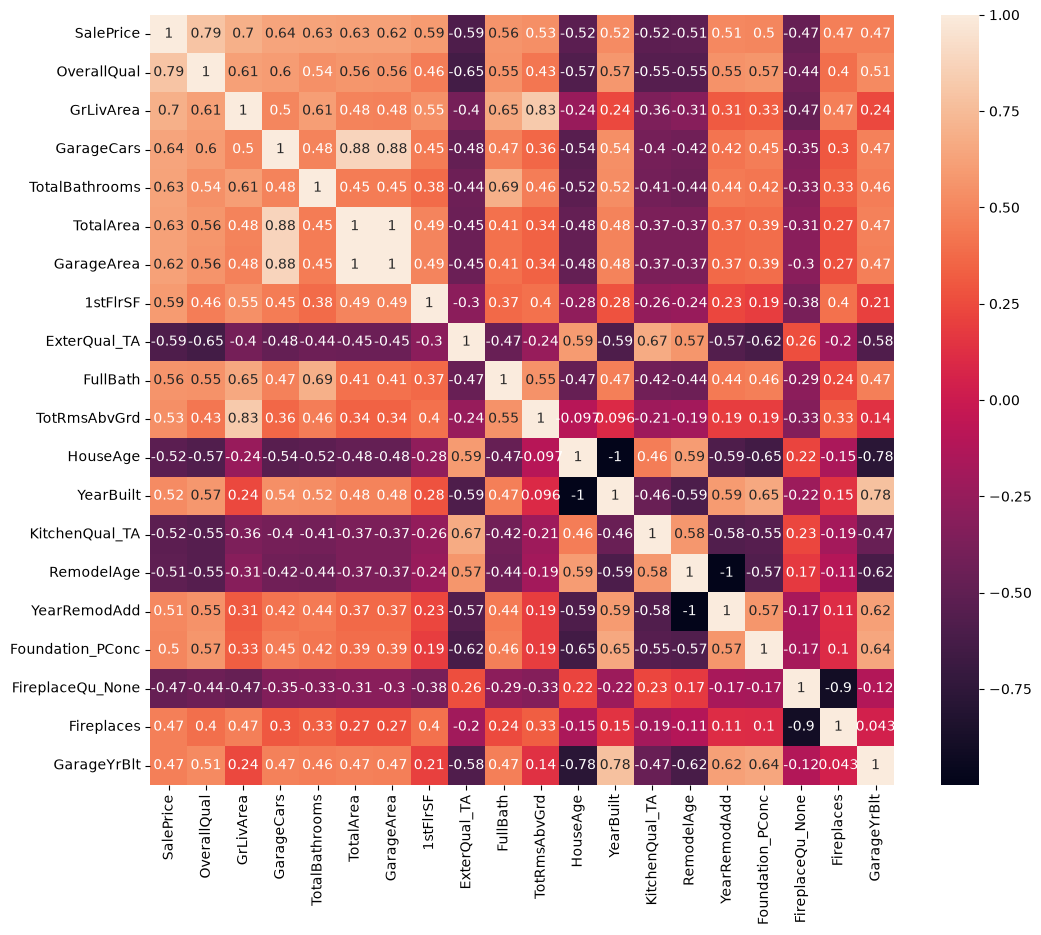

In [75]:
top_features = saleprice_corr.abs().sort_values(ascending=False).head(20).index

plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True)

plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/heatmap.png", dpi=300)
plt.show()
plt.close()

# EDA

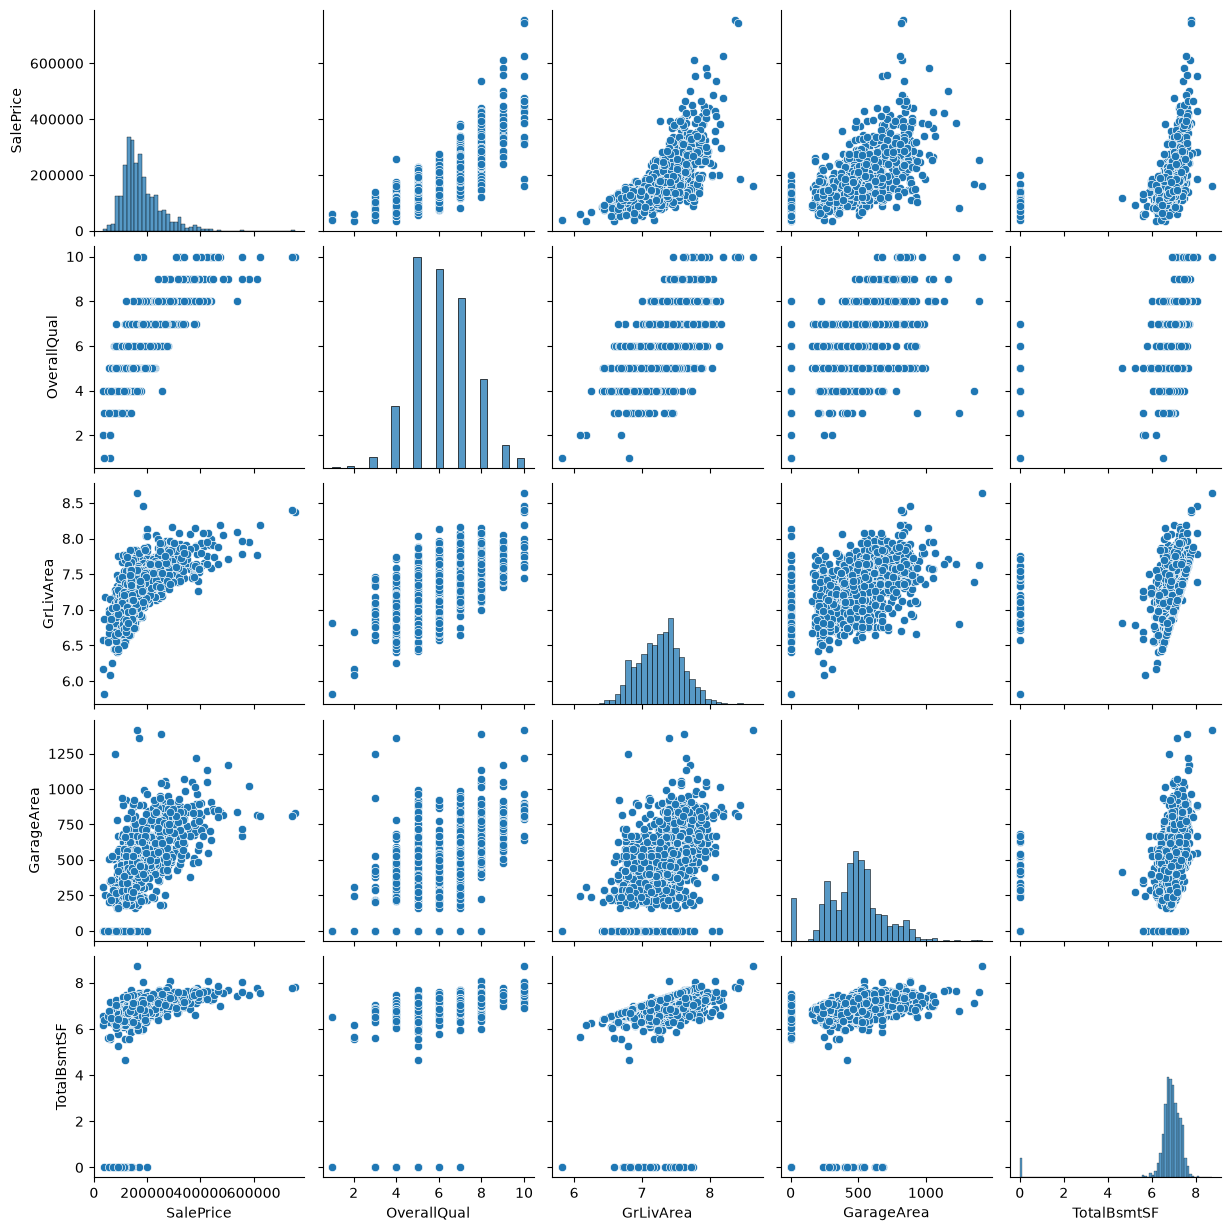

In [76]:
selected = [
    'SalePrice',
    'OverallQual',
    'GrLivArea',
    'GarageArea',
    'TotalBsmtSF'
]
sns.pairplot(df[selected])
plt.show()

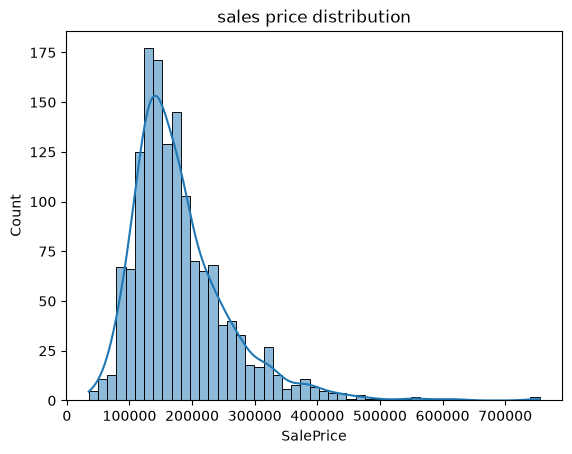

In [77]:
sns.histplot(df['SalePrice'], kde=True)
plt.title("sales price distribution")
plt.show()

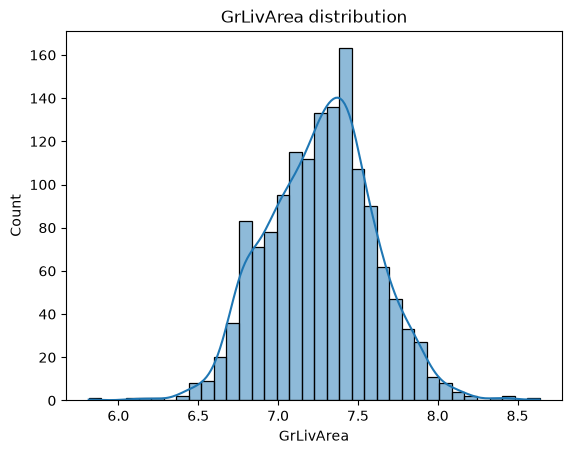

In [78]:
sns.histplot(df['GrLivArea'], kde=True)
plt.title("GrLivArea distribution")
plt.show()

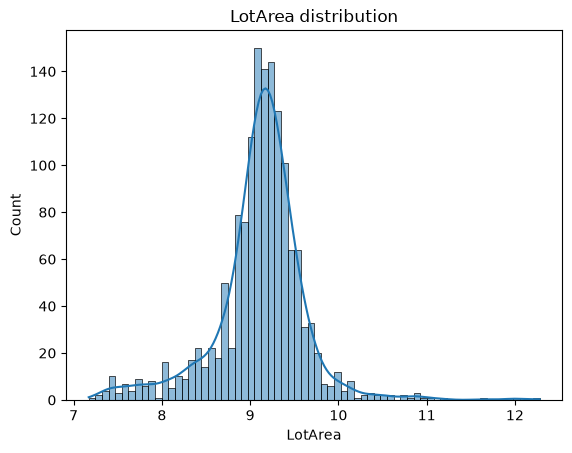

In [79]:
sns.histplot(df['LotArea'], kde=True)
plt.title("LotArea distribution")
plt.show()

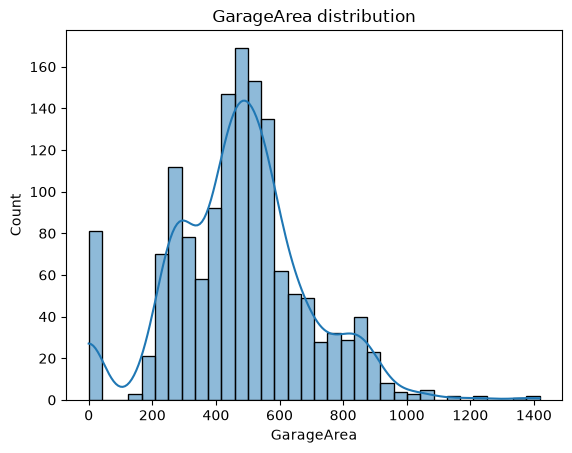

In [80]:
sns.histplot(df['GarageArea'], kde=True)
plt.title("GarageArea distribution")
plt.show()

In [81]:
corr = df.corr(numeric_only=True)
importance = corr['SalePrice'].abs().sort_values(ascending=False)
importance.head(15)

SalePrice         1.000000
OverallQual       0.790982
GrLivArea         0.695147
GarageCars        0.640409
TotalBathrooms    0.631731
TotalArea         0.625024
GarageArea        0.623431
1stFlrSF          0.591299
ExterQual_TA      0.589044
FullBath          0.560664
TotRmsAbvGrd      0.533723
HouseAge          0.523350
YearBuilt         0.522897
KitchenQual_TA    0.519298
RemodelAge        0.509079
Name: SalePrice, dtype: float64

# MODEL DEVELOPMENT

In [82]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

In [83]:
x = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [84]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [85]:
lr=LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](265,)","[ 1.33,-4667.64,17154.71,...,14026.83, 713.34, 4995.92]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](265,)","['MSSubClass','LotFrontage','LotArea',...,'TotalArea','TotalPorchSF', 'TotalLivingSF']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-5.889e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,265
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(248)


In [86]:
y_pred = lr.predict(x_test)

In [87]:
mae=mean_absolute_error(y_test,y_pred)
mse=mean_squared_error(y_test,y_pred)
rmse=np.sqrt(mse)
lr_r2=r2_score(y_test,y_pred)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",lr_r2)

mae: 21057.156713698474
mse: 1669732216.1883729
rmse: 40862.35695831033
r2 score: 0.7823127503203413


In [88]:
comparison = pd.DataFrame({"Actual": y_test,"Predicted": y_pred})
comparison.head(10)

,Actual,Predicted
892,154500,163799.300467
1105,325000,357518.722167
413,115000,83924.302255
522,159000,188485.068000
1036,315500,333912.887827
614,75500,61365.261590
218,311500,243535.429763
1160,146000,149316.012720
649,84500,61672.950646
887,135500,160677.862922


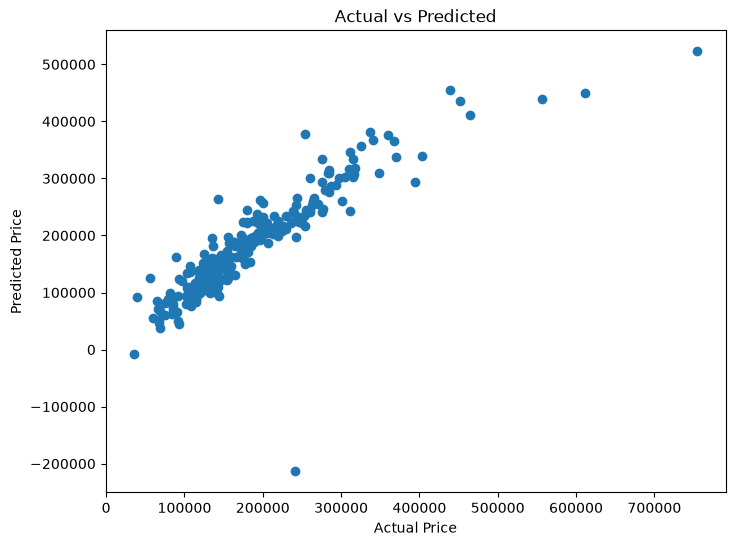

In [89]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

In [90]:
results = pd.DataFrame(columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R2"
])
results.loc[len(results)] = [
    "Linear Regression",
    mae,
    mse,
    rmse,
    lr_r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313


In [91]:
dt = DecisionTreeRegressor(random_state=42)

In [92]:
dt.fit(x_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes 

In [93]:
y_pred_dt = dt.predict(x_test)

In [94]:
mae=mean_absolute_error(y_test,y_pred_dt)
mse=mean_squared_error(y_test,y_pred_dt)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_dt)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 25757.880136986303
mse: 1454466199.0856164
rmse: 38137.46450782506
r2 score: 0.8103775302642571


In [95]:
comparison = pd.DataFrame({"Actual": y_test,"Predicted": y_pred_dt})
comparison.head(10)

,Actual,Predicted
892,154500,154000.0
1105,325000,424870.0
413,115000,109900.0
522,159000,163000.0
1036,315500,285000.0
614,75500,86000.0
218,311500,214900.0
1160,146000,148500.0
649,84500,86000.0
887,135500,140000.0


In [96]:
results.loc[len(results)] = [
    "Decision Tree",
    mae,
    mse,
    rmse,
    r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378


In [97]:
rf=RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [98]:
y_pred_rf = rf.predict(x_test)

In [99]:
mae=mean_absolute_error(y_test,y_pred_rf)
mse=mean_squared_error(y_test,y_pred_rf)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_rf)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 17462.50198630137
mse: 830439337.5353663
rmse: 28817.344387284655
r2 score: 0.8917335045337131


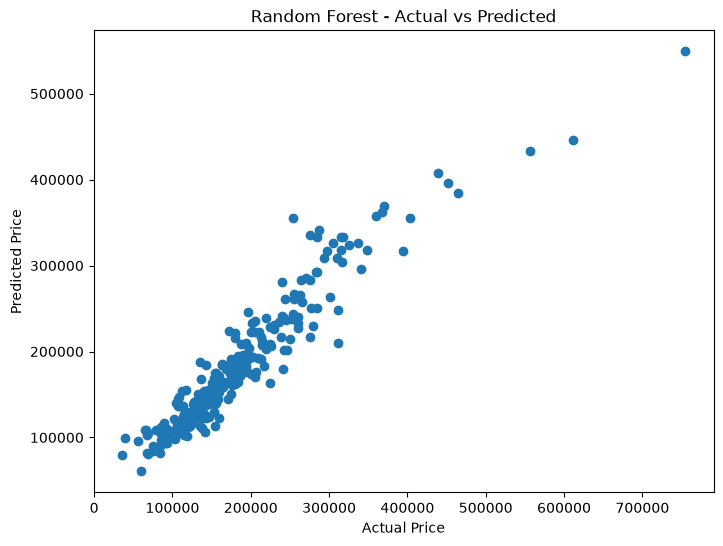

In [100]:
plt.figure(figsize=(8,6))
plt.scatter(
    y_test,
    y_pred_rf
)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Random Forest - Actual vs Predicted")
plt.show()

In [101]:
results.loc[len(results)] = [
    "Random Forest",
    mae,
    mse,
    rmse,
    r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734


In [102]:
gbm = GradientBoostingRegressor(random_state=42)

In [103]:
gbm.fit(x_train,y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf

In [104]:
y_pred_gbm=gbm.predict(x_test)

In [105]:
mae=mean_absolute_error(y_test,y_pred_gbm)
mse=mean_squared_error(y_test,y_pred_gbm)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_gbm)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 17468.04703075142
mse: 719977538.2518985
rmse: 26832.397176769326
r2 score: 0.9061346911716379


In [106]:
results.loc[len(results)] = [
    "Gradient Boosting",
    mae,
    mse,
    rmse,
    r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135


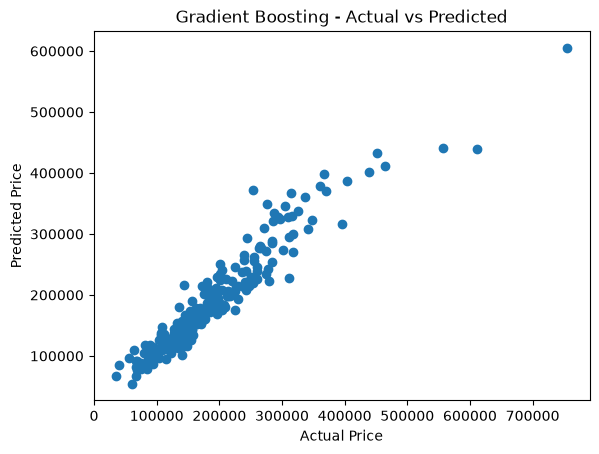

In [107]:
plt.scatter(y_test,y_pred_gbm)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Gradient Boosting - Actual vs Predicted")
plt.show()

In [108]:
xgb = XGBRegressor(random_state=42)

In [109]:
xgb.fit(x_train,y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [110]:
y_pred_xgb = xgb.predict(x_test)

In [111]:
mae=mean_absolute_error(y_test,y_pred_xgb)
mse=mean_squared_error(y_test,y_pred_xgb)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_xgb)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 17893.177734375
mse: 822444288.0
rmse: 28678.289488740433
r2 score: 0.89277583360672


In [112]:
results.loc[len(results)] = [
    "XGBoost",
    mae,
    mse,
    rmse,
    r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135
4,XGBoost,17893.177734,8.224443e+08,28678.289489,0.892776


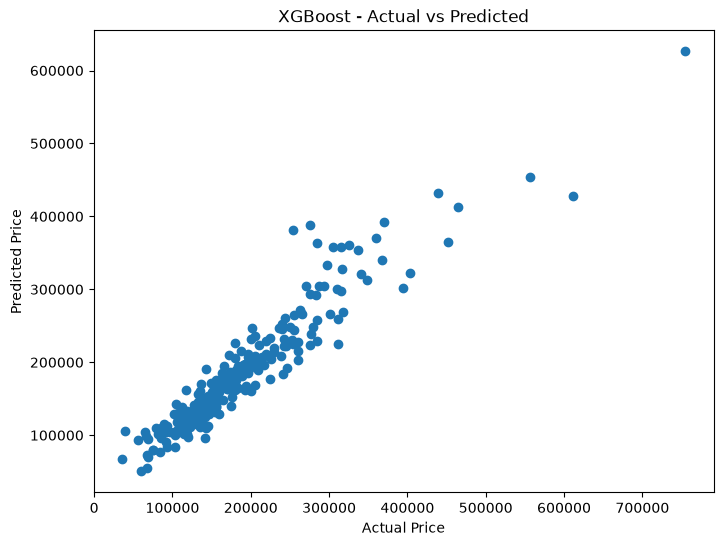

In [113]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_xgb)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("XGBoost - Actual vs Predicted")
plt.show()

In [114]:
lgbm = LGBMRegressor(random_state=42)

In [115]:
lgbm.fit(x_train,y_train)

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002459 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4109
[LightGBM] [Info] Number of data points in the train set: 1168, number of used features: 175
[LightGBM] [Info] Start training from score 181441.541952


,random_state,42
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001


In [116]:
y_pred_lgbm = lgbm.predict(x_test)

In [117]:
mae=mean_absolute_error(y_test,y_pred_lgbm)
mse=mean_squared_error(y_test,y_pred_lgbm)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_lgbm)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 16440.84634262819
mse: 811472461.5850893
rmse: 28486.355709095
r2 score: 0.8942062645491222


In [118]:
results.loc[len(results)] = [
    "LightGBM",
    mae,
    mse,
    rmse,
    r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135
4,XGBoost,17893.177734,8.224443e+08,28678.289489,0.892776
5,LightGBM,16440.846343,8.114725e+08,28486.355709,0.894206


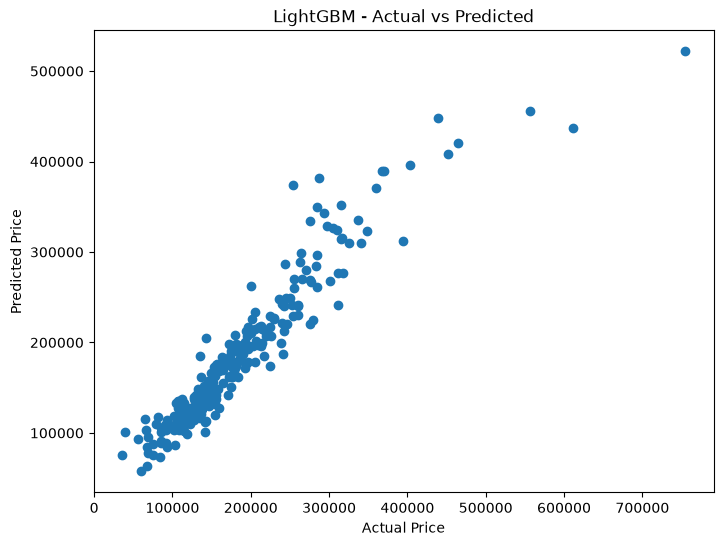

In [119]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_lgbm)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("LightGBM - Actual vs Predicted")
plt.show()

In [120]:
cat = CatBoostRegressor(random_state=42,verbose=0)

In [121]:
cat.fit(x_train,y_train)

CatBoostRegressor(loss_function='RMSE', random_state=42, verbose=0)

In [122]:
y_pred_cat = cat.predict(x_test)

In [123]:
mae=mean_absolute_error(y_test,y_pred_cat)
mse=mean_squared_error(y_test,y_pred_cat)
rmse=np.sqrt(mse)
r2=r2_score(y_test,y_pred_cat)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 15530.090702253505
mse: 651852033.9259907
rmse: 25531.39310586069
r2 score: 0.915016387006435


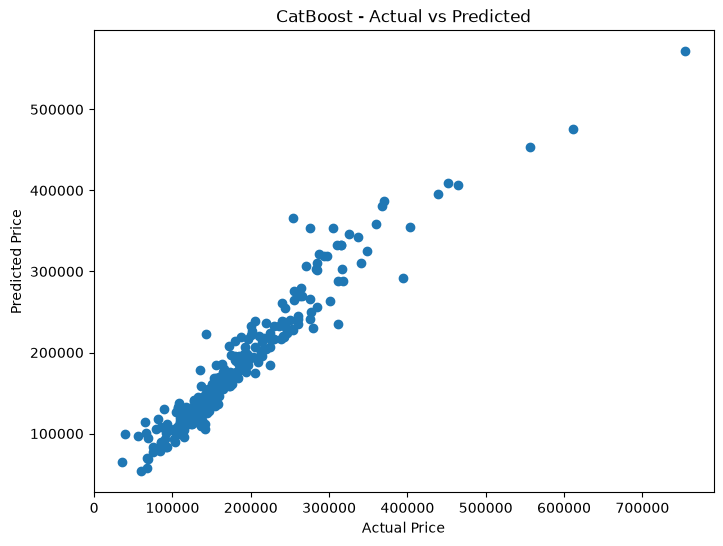

In [124]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred_cat)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("CatBoost - Actual vs Predicted")
plt.show()

In [125]:
results.loc[len(results)] = [
    "CatBoost",
    mae,
    mse,
    rmse,
    r2
]
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135
4,XGBoost,17893.177734,8.224443e+08,28678.289489,0.892776
5,LightGBM,16440.846343,8.114725e+08,28486.355709,0.894206
6,CatBoost,15530.090702,6.518520e+08,25531.393106,0.915016


In [126]:
baseline_results = results.copy()

In [127]:
best_rmse_model = baseline_results.sort_values(by="RMSE")
best_rmse_model

,Model,MAE,MSE,RMSE,R2
6,CatBoost,15530.090702,6.518520e+08,25531.393106,0.915016
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135
5,LightGBM,16440.846343,8.114725e+08,28486.355709,0.894206
4,XGBoost,17893.177734,8.224443e+08,28678.289489,0.892776
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313


In [128]:
best_r2_model = baseline_results.sort_values(by="R2",ascending=False)
best_r2_model

,Model,MAE,MSE,RMSE,R2
6,CatBoost,15530.090702,6.518520e+08,25531.393106,0.915016
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135
5,LightGBM,16440.846343,8.114725e+08,28486.355709,0.894206
4,XGBoost,17893.177734,8.224443e+08,28678.289489,0.892776
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313


In [129]:
baseline_results.to_csv("baseline_model_results.csv",index=False)

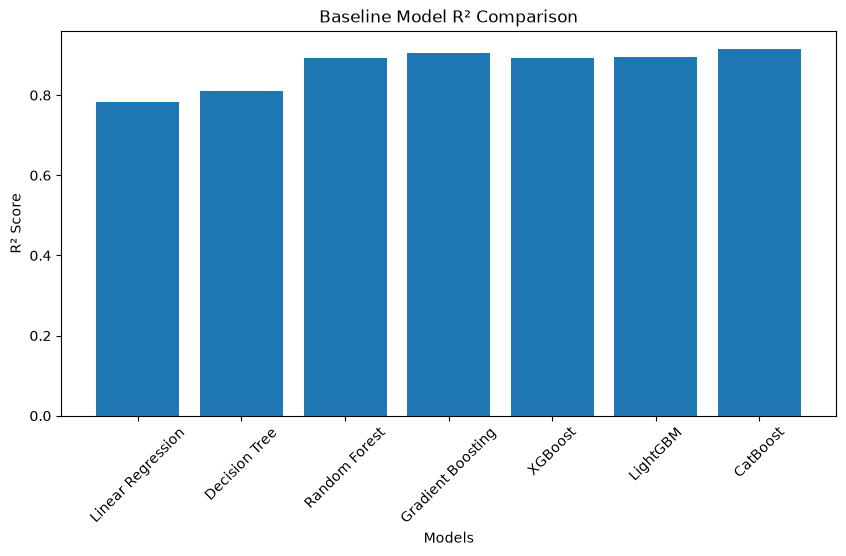

In [130]:
plt.figure(figsize=(10,5))
plt.bar(baseline_results["Model"],baseline_results["R2"])
plt.xticks(rotation=45)
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.title("Baseline Model R² Comparison")
plt.show()

In [131]:
importance = pd.DataFrame({"Feature": x_train.columns,"Importance": rf.feature_importances_})

In [132]:
importance = importance.sort_values(by="Importance",ascending=False)
importance.head(20)

,Feature,Importance
3,OverallQual,0.553004
15,GrLivArea,0.097833
264,TotalLivingSF,0.037230
11,TotalBsmtSF,0.031552
13,2ndFlrSF,0.029745
12,1stFlrSF,0.026320
8,BsmtFinSF1,0.025858
261,TotalBathrooms,0.015272
2,LotArea,0.014878
262,TotalArea,0.012942


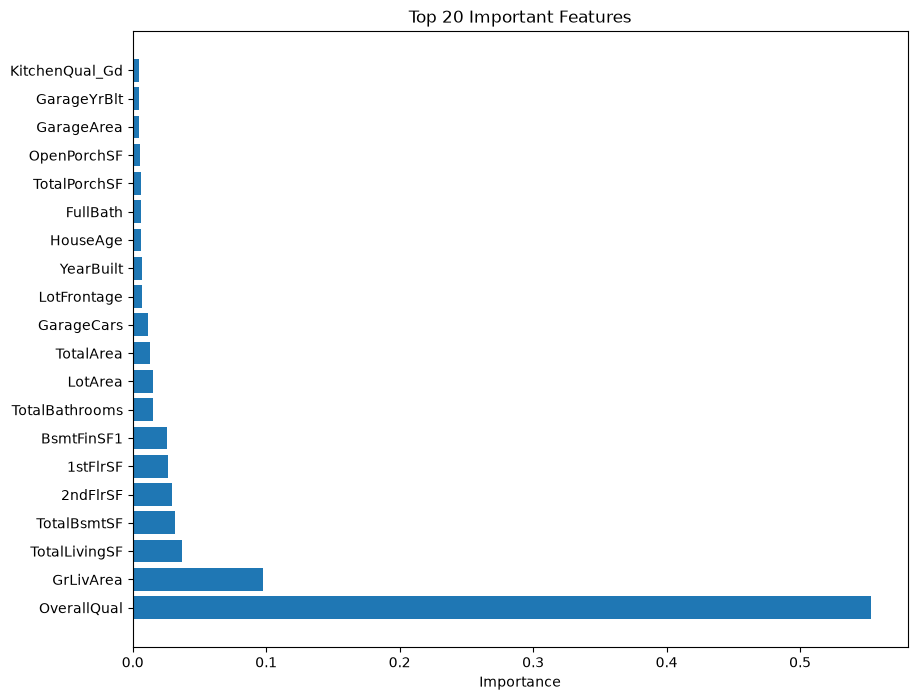

In [133]:
top20 = importance.head(20)
plt.figure(figsize=(10,8))
plt.barh(top20["Feature"],top20["Importance"])
plt.title("Top 20 Important Features")
plt.xlabel("Importance")

plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/feature_importance.png", dpi=300)
plt.show()
plt.close()

In [134]:
selected_features = importance[importance["Importance"] > 0.001]["Feature"]
selected_features

3            OverallQual
15             GrLivArea
264        TotalLivingSF
11           TotalBsmtSF
13              2ndFlrSF
12              1stFlrSF
8             BsmtFinSF1
261       TotalBathrooms
2                LotArea
262            TotalArea
25            GarageCars
1            LotFrontage
5              YearBuilt
259             HouseAge
18              FullBath
263         TotalPorchSF
28           OpenPorchSF
26            GarageArea
24           GarageYrBlt
201       KitchenQual_Gd
10             BsmtUnfSF
163          BsmtQual_Gd
6           YearRemodAdd
27            WoodDeckSF
22          TotRmsAbvGrd
7             MasVnrArea
260           RemodelAge
195         CentralAir_Y
34                MoSold
4            OverallCond
31           ScreenPorch
0             MSSubClass
23            Fireplaces
218    GarageType_Detchd
45          LotShape_Reg
151         ExterQual_Gd
214    GarageType_Attchd
20          BedroomAbvGr
35                YrSold
170      BsmtExposure_Gd


In [135]:
x_selected = x[selected_features]

In [136]:
x_train_sel, x_test_sel, y_train_sel, y_test_sel = train_test_split(
    x_selected,
    y,
    test_size=0.2,
    random_state=42
)

In [137]:
rf = RandomForestRegressor(random_state=42)
rf.fit(x_train_sel, y_train_sel)
y_pred = rf.predict(x_test_sel)

In [138]:
mae=mean_absolute_error(y_test_sel,y_pred)
mse=mean_squared_error(y_test_sel,y_pred)
rmse=np.sqrt(mse)
r2=r2_score(y_test_sel,y_pred)
print("mae:",mae)
print("mse:",mse)
print("rmse:",rmse)
print("r2 score:",r2)

mae: 17381.131541095892
mse: 791903307.9354715
rmse: 28140.776605052524
r2 score: 0.8967575450450262


In [139]:
comparison = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R2"],
    "Before": [
        baseline_results.loc[
            baseline_results["Model"]=="Random Forest",
            "MAE"
        ].values[0],
        baseline_results.loc[
            baseline_results["Model"]=="Random Forest",
            "MSE"
        ].values[0],
        baseline_results.loc[
            baseline_results["Model"]=="Random Forest",
            "RMSE"
        ].values[0],
        baseline_results.loc[
            baseline_results["Model"]=="Random Forest",
            "R2"
        ].values[0]
    ],
    "After":[
        mae,
        mse,
        rmse,
        r2
    ]
})
comparison

,Metric,Before,After
0,MAE,1.746250e+04,1.738113e+04
1,MSE,8.304393e+08,7.919033e+08
2,RMSE,2.881734e+04,2.814078e+04
3,R2,8.917335e-01,8.967575e-01


In [140]:
x=df.drop("SalePrice",axis=1)

In [141]:
vif = pd.DataFrame()
vif["Feature"] = x.columns
vif["VIF"] = [
    variance_inflation_factor(x.values, i)
    for i in range(x.shape[1])
]
vif

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
0,MSSubClass,9.907596e+01
1,LotFrontage,6.474887e+02
2,LotArea,1.774887e+03
3,OverallQual,1.166603e+02
4,OverallCond,7.130288e+01
...,...,...
260,RemodelAge,inf
261,TotalBathrooms,3.743476e+05
262,TotalArea,5.931468e+07
263,TotalPorchSF,3.091727e+07


In [142]:
inf_features = vif[vif["VIF"]==np.inf]
inf_features

,Feature,VIF
5,YearBuilt,inf
6,YearRemodAdd,inf
35,YrSold,inf
121,Exterior1st_CBlock,inf
135,Exterior2nd_CBlock,inf
259,HouseAge,inf
260,RemodelAge,inf


In [143]:
x_vif = x.drop(columns=[
    'TotalBsmtSF',
    '2ndFlrSF',
    '1stFlrSF',
    'WoodDeckSF',
    'ScreenPorch',
    '3SsnPorch',
    'EnclosedPorch',
    'OpenPorchSF',
    'GarageArea',
    'TotalBsmtSF',
    'GrLivArea',
    'BsmtHalfBath',
    'BsmtFullBath',
    'HalfBath',
    'FullBath',
    'YearRemodAdd',
    'YearBuilt',
    'YrSold',
	'Exterior1st_CBlock',
    'Exterior2nd_CBlock',
	'BsmtQual_None',
	'BsmtCond_None',
	'BsmtFinType1_None',
	'GarageType_None',
	'GarageFinish_None',
	'GarageQual_None',
    'GarageCond_None',
	'HouseAge',
	'RemodelAge',
	'TotalBathrooms',
	'TotalPorchSF',
	'TotalLivingSF'

])

In [144]:
x_vif.shape

(1460, 234)

In [145]:
vif = pd.DataFrame()
vif["Feature"] = x_vif.columns
vif["VIF"] = [
    variance_inflation_factor(x_vif.values,i)for i in range(x_vif.shape[1])
]
vif.sort_values(
    "VIF",
    ascending=True
).head(20)

,Feature,VIF
69,Condition1_RRNe,1.165453
221,SaleType_Con,1.203283
142,Foundation_Wood,1.219909
35,LotConfig_FR3,1.223972
220,SaleType_CWD,1.283639
223,SaleType_ConLI,1.285203
32,Utilities_NoSeWa,1.301995
171,HeatingQC_Po,1.369999
26,LotShape_IR2,1.416163
121,Exterior2nd_Other,1.418556


In [146]:
X_train_vif, X_test_vif, y_train_vif, y_test_vif = train_test_split(
    x_vif,
    y,
    test_size=0.2,
    random_state=42
)

In [147]:
lr_vif = LinearRegression()
lr_vif.fit(X_train_vif, y_train_vif)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](234,)","[ -98.22,-5843.49,22801.44,..., 6228.89,14915.7 , 40.32]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](234,)","['MSSubClass','LotFrontage','LotArea',...,'SaleCondition_Normal', 'SaleCondition_Partial','TotalArea']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-8.337e+05
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,234
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(230)


In [148]:
y_pred_lr_vif = lr_vif.predict(X_test_vif)

In [149]:
mae = mean_absolute_error(y_test_vif, y_pred_lr_vif)
mse = mean_squared_error(y_test_vif, y_pred_lr_vif)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_vif, y_pred_lr_vif)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 :", r2)

MAE : 22207.46605703084
MSE : 1504840229.7420442
RMSE : 38792.27023186506
R2 : 0.8038101393481801


In [150]:
optimized_results=pd.DataFrame(columns=[
    "Model",
    "MAE",
    "MSE",
    "RMSE",
    "R2"
])
optimized_results.loc[len(optimized_results)] = [
    "Linear Regression (VIF)",
    mae,
    mse,
    rmse,
    r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.80381


In [151]:
df.shape

(1460, 266)

In [152]:
x = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [153]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [154]:
rf = RandomForestRegressor(random_state=42)
cv_rf = cross_val_score(rf,x_train,y_train,cv=5,scoring="r2")
cv_rf_mean = np.mean(cv_rf)

In [155]:
lr = LinearRegression()
cv_lr = cross_val_score(lr,x_train,y_train,cv=5,scoring='r2')
print(cv_lr)
print("Average:", np.mean(cv_lr))

[0.83653784 0.60037948 0.77107688 0.70869576 0.68791755]
Average: 0.7209215012299178


In [156]:
cv_lr_mean = np.mean(cv_lr)

In [157]:
dt = DecisionTreeRegressor(random_state=42)
cv_dt = cross_val_score(dt,x_train,y_train,cv=5,scoring='r2')
cv_dt_mean = np.mean(cv_dt)

In [158]:
gb = GradientBoostingRegressor(random_state=42)
cv_gb = cross_val_score(gb,x_train,y_train,cv=5,scoring='r2')
cv_gb_mean = np.mean(cv_gb)

In [159]:
xgb = XGBRegressor(random_state=42)
cv_xgb = cross_val_score(xgb,x_train,y_train,cv=5,scoring='r2')
cv_xgb_mean = np.mean(cv_xgb)

In [160]:
lgb = LGBMRegressor(random_state=42,verbose=-1)
cv_lgb = cross_val_score(lgb,x_train,y_train,cv=5,scoring='r2')
cv_lgb_mean = np.mean(cv_lgb)

In [161]:
cat = CatBoostRegressor(verbose=0,random_state=42)
cv_cat = cross_val_score(cat,x_train,y_train,cv=5,scoring='r2')
cv_cat_mean = np.mean(cv_cat)

In [162]:
cv_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],
    "CV Mean R2": [
        cv_lr_mean,
        cv_dt_mean,
        cv_rf_mean,
        cv_gb_mean,
        cv_xgb_mean,
        cv_lgb_mean,
        cv_cat_mean
    ]
})
cv_results

,Model,CV Mean R2
0,Linear Regression,0.720922
1,Decision Tree,0.608421
2,Random Forest,0.840189
3,Gradient Boosting,0.856212
4,XGBoost,0.827539
5,LightGBM,0.848586
6,CatBoost,0.878877


In [163]:
results["CV Mean R2"] = [
    cv_lr_mean,
    cv_dt_mean,
    cv_rf_mean,
    cv_gb_mean,
    cv_xgb_mean,
    cv_lgb_mean,
    cv_cat_mean
]
results

,Model,MAE,MSE,RMSE,R2,CV Mean R2
0,Linear Regression,21057.156714,1.669732e+09,40862.356958,0.782313,0.720922
1,Decision Tree,25757.880137,1.454466e+09,38137.464508,0.810378,0.608421
2,Random Forest,17462.501986,8.304393e+08,28817.344387,0.891734,0.840189
3,Gradient Boosting,17468.047031,7.199775e+08,26832.397177,0.906135,0.856212
4,XGBoost,17893.177734,8.224443e+08,28678.289489,0.892776,0.827539
5,LightGBM,16440.846343,8.114725e+08,28486.355709,0.894206,0.848586
6,CatBoost,15530.090702,6.518520e+08,25531.393106,0.915016,0.878877


In [164]:
x = df.drop("SalePrice", axis=1)
y = df["SalePrice"]

In [165]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [166]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [167]:
grid_rf = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=5,
    n_jobs=-1
)
grid_rf.fit(x_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestR...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose ver

In [168]:
best_rf = grid_rf.best_estimator_

In [169]:
y_pred = best_rf.predict(x_test)

In [170]:
rf_mae = mean_absolute_error(y_test, y_pred)
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = np.sqrt(mse)
rf_r2 = r2_score(y_test, y_pred)

print(rf_mae)
print(rf_rmse)
print(rf_r2)

17637.005136433872
38792.27023186506
0.8931792260526666


In [171]:
param_grid = {
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',n_jobs=-1)
grid_dt.fit(x_train, y_train)
print(grid_dt.best_params_)
best_dt = grid_dt.best_estimator_
y_pred = best_dt.predict(x_test)

{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 10}


In [172]:
dt_mae = mean_absolute_error(y_test, y_pred)
dt_mse = mean_squared_error(y_test, y_pred)
dt_rmse = np.sqrt(mse)
dt_r2 = r2_score(y_test, y_pred)

print(dt_mae)
print(dt_rmse)
print(dt_r2)

26995.610378614914
38792.27023186506
0.785219261394674


In [173]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),param_grid,cv=5,scoring='r2',n_jobs=-1
)
grid_gb.fit(x_train, y_train)
print(grid_gb.best_params_)
best_gb = grid_gb.best_estimator_
y_pred = best_gb.predict(x_test)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [174]:
gb_mae = mean_absolute_error(y_test, y_pred)
gb_mse = mean_squared_error(y_test, y_pred)
gb_rmse = np.sqrt(mse)
gb_r2 = r2_score(y_test, y_pred)

print(gb_mae)
print(gb_rmse)
print(gb_r2)

16166.14918190724
38792.27023186506
0.9150119912229874


In [175]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),param_grid,cv=5,scoring='r2',n_jobs=-1
)
grid_xgb.fit(x_train, y_train)
print(grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(x_test)

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [176]:
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(mse)
xgb_r2 = r2_score(y_test, y_pred)

print(xgb_mae)
print(xgb_rmse)
print(xgb_r2)

16353.669921875
38792.27023186506
0.917848527431488


In [177]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [10, 20],
    'num_leaves': [31, 50]
}
grid_lgb = GridSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),param_grid,cv=5,scoring='r2',n_jobs=-1
)
grid_lgb.fit(x_train, y_train)
print(grid_lgb.best_params_)
best_lgb = grid_lgb.best_estimator_
y_pred = best_lgb.predict(x_test)

{'learning_rate': 0.05, 'max_depth': 20, 'n_estimators': 100, 'num_leaves': 50}


In [178]:
lgb_mae = mean_absolute_error(y_test, y_pred)
lgb_mse = mean_squared_error(y_test, y_pred)
lgb_rmse = np.sqrt(mse)
lgb_r2 = r2_score(y_test, y_pred)

print(lgb_mae)
print(lgb_rmse)
print(lgb_r2)

16622.998330064245
38792.27023186506
0.8829354979003987


In [179]:
param_grid = {
    'iterations': [100, 200, 500],
    'learning_rate': [0.05, 0.1],
    'depth': [4, 6, 8]
}
grid_cat = GridSearchCV(
    CatBoostRegressor(verbose=0, random_state=42),param_grid,cv=5,scoring='r2',n_jobs=-1
)
grid_cat.fit(x_train, y_train)
print(grid_cat.best_params_)
best_cat = grid_cat.best_estimator_
cat_pred = best_cat.predict(x_test)

{'depth': 6, 'iterations': 500, 'learning_rate': 0.05}


In [180]:
cat_mae = mean_absolute_error(y_test, cat_pred)
cat_mse = mean_squared_error(y_test, cat_pred)
cat_rmse = np.sqrt(mse)
cat_r2 = r2_score(y_test, cat_pred)

print(cat_mae)
print(cat_rmse)
print(cat_r2)

15524.677055572261
38792.27023186506
0.9155900442486349


In [181]:
tuned_df = pd.DataFrame({
    "Model": [
        "Decision Tree (Tuned)",
        "Random Forest (Tuned)",
        "Gradient Boosting (Tuned)",
        "XGBoost (Tuned)",
        "LightGBM (Tuned)",
        "CatBoost (Tuned)"
    ],
    "MAE": [
        dt_mae,
        rf_mae,
        gb_mae,
        xgb_mae,
        lgb_mae,
        cat_mae
    ],
    "MSE": [
        dt_mse,
        rf_mse,
        gb_mse,
        xgb_mse,
        lgb_mse,
        cat_mse
    ],
    "RMSE": [
        dt_rmse,
        rf_rmse,
        gb_rmse,
        xgb_rmse,
        lgb_rmse,
        cat_rmse
    ],
    "R2": [
        dt_r2,
        rf_r2,
        gb_r2,
        xgb_r2,
        lgb_r2,
        cat_r2
    ]
})
tuned_df

,Model,MAE,MSE,RMSE,R2
0,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219
1,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
2,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012
3,XGBoost (Tuned),16353.669922,6.301287e+08,38792.270232,0.917849
4,LightGBM (Tuned),16622.998330,8.979229e+08,38792.270232,0.882935
5,CatBoost (Tuned),15524.677056,6.474519e+08,38792.270232,0.915590


In [182]:
best_r2_score = tuned_df.sort_values(by="R2",ascending=False)
best_r2_score

,Model,MAE,MSE,RMSE,R2
3,XGBoost (Tuned),16353.669922,6.301287e+08,38792.270232,0.917849
5,CatBoost (Tuned),15524.677056,6.474519e+08,38792.270232,0.915590
2,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012
1,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
4,LightGBM (Tuned),16622.998330,8.979229e+08,38792.270232,0.882935
0,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219


In [183]:
optimized_results.loc[len(optimized_results)] = [
    "Decision Tree (Tuned)",
    dt_mae,
    dt_mse,
    dt_rmse,
    dt_r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219


In [184]:
optimized_results.loc[len(optimized_results)] = [
   "Random Forest (Tuned)",
    rf_mae,
    rf_mse,
    rf_rmse,
    rf_r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219
2,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179


In [185]:
optimized_results.loc[len(optimized_results)] = [
   "Gradient Boosting (Tuned)",
    gb_mae,
    gb_mse,
    gb_rmse,
    gb_r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219
2,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
3,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012


In [186]:
optimized_results.loc[len(optimized_results)] = [
   "XGBoost (Tuned)",
    xgb_mae,
    xgb_mse,
    xgb_rmse,
    xgb_r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219
2,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
3,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012
4,XGBoost (Tuned),16353.669922,6.301287e+08,38792.270232,0.917849


In [187]:
optimized_results.loc[len(optimized_results)] = [
   "LightGBM (Tuned)",
    lgb_mae,
    lgb_mse,
    lgb_rmse,
    lgb_r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219
2,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
3,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012
4,XGBoost (Tuned),16353.669922,6.301287e+08,38792.270232,0.917849
5,LightGBM (Tuned),16622.998330,8.979229e+08,38792.270232,0.882935


In [188]:
optimized_results.loc[len(optimized_results)] = [
   "CatBoost (Tuned)",
    cat_mae,
    cat_mse,
    cat_rmse,
    cat_r2
]
optimized_results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219
2,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
3,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012
4,XGBoost (Tuned),16353.669922,6.301287e+08,38792.270232,0.917849
5,LightGBM (Tuned),16622.998330,8.979229e+08,38792.270232,0.882935
6,CatBoost (Tuned),15524.677056,6.474519e+08,38792.270232,0.915590


In [189]:
best_optimized_r2 = optimized_results.sort_values(by="R2",ascending=False)
best_optimized_r2

,Model,MAE,MSE,RMSE,R2
4,XGBoost (Tuned),16353.669922,6.301287e+08,38792.270232,0.917849
6,CatBoost (Tuned),15524.677056,6.474519e+08,38792.270232,0.915590
3,Gradient Boosting (Tuned),16166.149182,6.518858e+08,38792.270232,0.915012
2,Random Forest (Tuned),17637.005136,8.193502e+08,38792.270232,0.893179
5,LightGBM (Tuned),16622.998330,8.979229e+08,38792.270232,0.882935
0,Linear Regression (VIF),22207.466057,1.504840e+09,38792.270232,0.803810
1,Decision Tree (Tuned),26995.610379,1.647438e+09,38792.270232,0.785219


In [190]:
optimized_results.to_csv("optimized_results.csv",index=False)

# MODEL EVALUATION AND COMPARISON

In [191]:
import joblib

In [192]:
x=df[[
    "TotalArea",
    "OverallQual",
    "TotalLivingSF",
    "GrLivArea",
    "GarageCars",
    "TotalBathrooms",
    "GarageArea",
    "TotalBsmtSF",      
    "YearBuilt",
    "YearRemodAdd"
]]
y = df["SalePrice"]

In [193]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [194]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'subsample': [0.8, 1.0]
}
grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42),param_grid,cv=5,scoring='r2',n_jobs=-1
)
grid_xgb.fit(x_train, y_train)
print(grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_
y_pred = best_xgb.predict(x_test)

{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 1.0}


In [195]:
xgb_mae = mean_absolute_error(y_test, y_pred)
xgb_mse = mean_squared_error(y_test, y_pred)
xgb_rmse = np.sqrt(mse)
xgb_r2 = r2_score(y_test, y_pred)

print(xgb_mae)
print(xgb_rmse)
print(xgb_r2)

18614.55078125
38792.27023186506
0.8935685157775879


In [196]:
joblib.dump(best_xgb,"/Users/aximsoft/Downloads/week_06/final_model.pkl")
print("Model Saved Successfully")

Model Saved Successfully


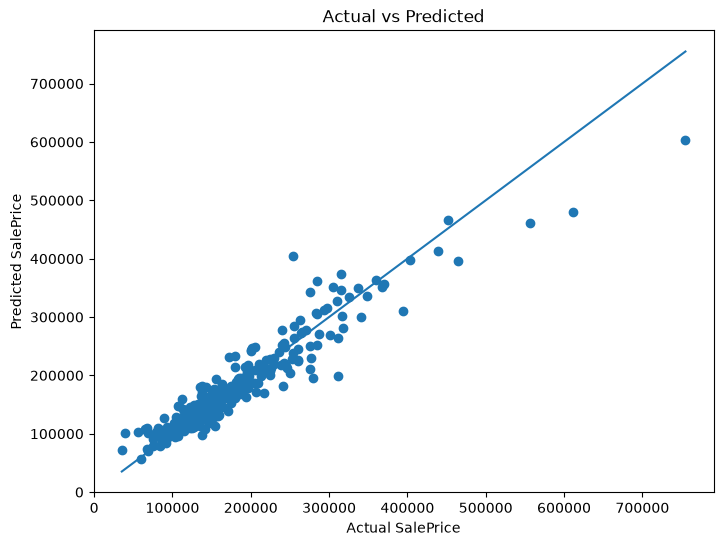

In [197]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
)
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("Actual vs Predicted")

plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/actual_vs_predicted.png", dpi=300)
plt.show()
plt.close()

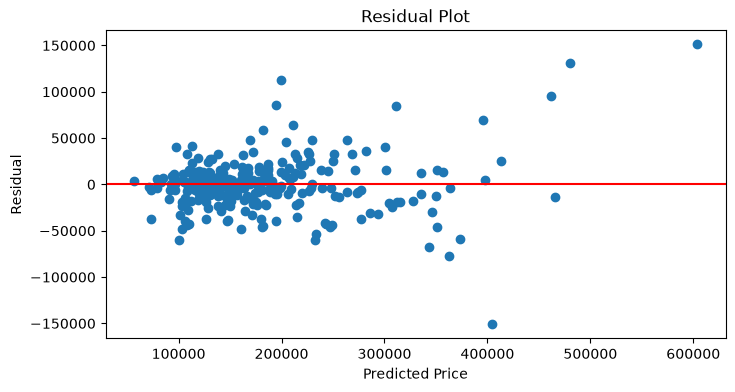

In [198]:
residual = y_test - y_pred
plt.figure(figsize=(8,4))
plt.scatter(y_pred, residual)
plt.axhline(0, color='red')
plt.xlabel("Predicted Price")
plt.ylabel("Residual")
plt.title("Residual Plot")

plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/residual_plot.png", dpi=300)
plt.show()
plt.close()

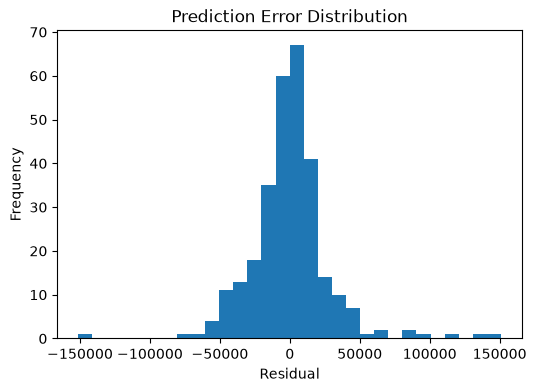

In [199]:
plt.figure(figsize=(6,4))
plt.hist(residual, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Prediction Error Distribution")
plt.show()

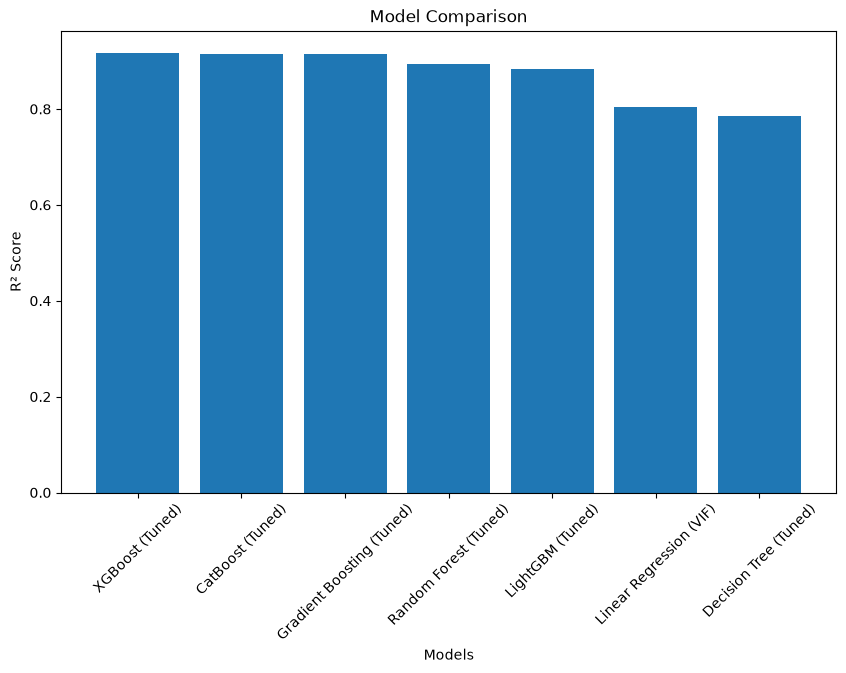

In [200]:
plt.figure(figsize=(10,6))
plt.bar(best_optimized_r2['Model'],best_optimized_r2['R2'])
plt.title("Model Comparison")
plt.xlabel("Models")
plt.ylabel("R² Score")
plt.xticks(rotation=45)

plt.savefig("/Users/aximsoft/Downloads/week_06/flask_app/static/plots/model_comparison.png", dpi=300)
plt.show()
plt.close()